In [3]:
print("Colab is working! Let's build a Fake News Detector!")

Colab is working! Let's build a Fake News Detector!


In [4]:
# Installing the libraries our AI model needs
!pip install pandas numpy scikit-learn matplotlib seaborn

In [7]:
import pandas as pd

# Check if file downloaded
import os
print(os.listdir())

['.config', 'sample_data']


In [9]:
import pandas as pd

# Load with error handling for messy characters
fake = pd.read_csv("Fake.csv", on_bad_lines='skip', engine='python')
real = pd.read_csv("True.csv", on_bad_lines='skip', engine='python')

# Add labels — 1 = Fake, 0 = Real
fake["label"] = 1
real["label"] = 0

# Combine into one dataset
df = pd.concat([fake, real], ignore_index=True)

print("Dataset loaded successfully!")
print(f"Total articles: {len(df)}")
print(f"Fake articles: {len(fake)}")
print(f"Real articles: {len(real)}")
df.head()

Dataset loaded successfully!
Total articles: 37853
Fake articles: 17799
Real articles: 20054


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


Dataset shape: (37853, 5)

Any missing values?
title      0
text       0
subject    0
date       0
label      0
dtype: int64


/tmp/ipykernel_7554/1572931439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['green','red'])


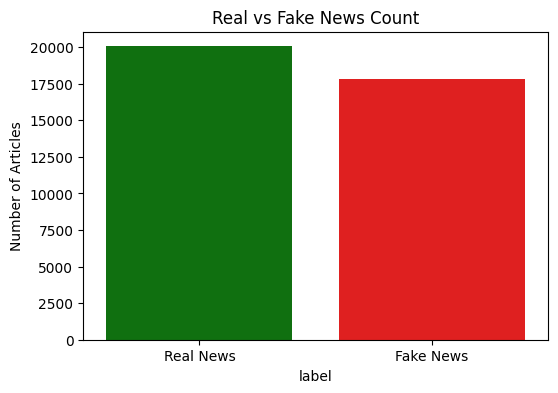

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check the shape
print(f"Dataset shape: {df.shape}")
print(f"\nAny missing values?\n{df.isnull().sum()}")

# Visualize fake vs real count
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['green','red'])
plt.xticks([0, 1], ['Real News', 'Fake News'])
plt.title('Real vs Fake News Count')
plt.ylabel('Number of Articles')
plt.show()

In [11]:
import re

# Combine title and text into one column
df['content'] = df['title'] + " " + df['text']

# Clean function — removes punctuation, numbers, extra spaces
def clean_text(text):
    text = text.lower()                        # make everything lowercase
    text = re.sub(r'\[.*?\]', '', text)        # remove text inside brackets
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove numbers & punctuation
    text = re.sub(r'\s+', ' ', text).strip()   # remove extra spaces
    return text

# Apply cleaning to all 37,853 articles
df['content'] = df['content'].apply(clean_text)

print("Cleaning done!")
print("\nSample cleaned article:")
print(df['content'][0][:300])

Cleaning done!

Sample cleaned article:
donald trump sends out embarrassing new years eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one j


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Convert text to numbers
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X = vectorizer.fit_transform(df['content'])
y = df['label']

# Split data — 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training data: {X_train.shape[0]} articles")
print(f"Testing data: {X_test.shape[0]} articles")
print(f"Total features (words): {X_train.shape[1]}")

Training data: 30282 articles
Testing data: 7571 articles
Total features (words): 10000


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create the AI model
model = LogisticRegression(max_iter=1000)

# TRAIN — AI learns from 30,282 articles
print("Training the AI... please wait!")
model.fit(X_train, y_train)

# TEST — AI predicts on 7,571 unseen articles
predictions = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\n✅ AI Training Complete!")
print(f"🎯 Accuracy: {accuracy * 100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, predictions, target_names=['Real News', 'Fake News']))

Training the AI... please wait!

✅ AI Training Complete!
🎯 Accuracy: 98.67%

Detailed Report:
              precision    recall  f1-score   support

   Real News       0.98      0.99      0.99      4018
   Fake News       0.99      0.98      0.99      3553

    accuracy                           0.99      7571
   macro avg       0.99      0.99      0.99      7571
weighted avg       0.99      0.99      0.99      7571



In [14]:
def predict_news(news_text):
    # Clean the input
    cleaned = clean_text(news_text)
    # Convert to numbers
    vectorized = vectorizer.transform([cleaned])
    # Predict
    prediction = model.predict(vectorized)[0]
    confidence = model.predict_proba(vectorized)[0]

    if prediction == 1:
        print(f"🚨 FAKE NEWS detected!")
        print(f"Confidence: {confidence[1]*100:.2f}%")
    else:
        print(f"✅ REAL NEWS!")
        print(f"Confidence: {confidence[0]*100:.2f}%")

# Test 1 — Obviously fake
predict_news("BREAKING: Aliens land in New York, shake hands with Donald Trump!")

print("---")

# Test 2 — Real style news
predict_news("The Federal Reserve raised interest rates by 0.25% on Wednesday following inflation concerns.")

🚨 FAKE NEWS detected!
Confidence: 96.15%
---
✅ REAL NEWS!
Confidence: 81.68%


In [16]:
# Type any news headline you want to test!
predict_news("Godwin was fallen to death")

🚨 FAKE NEWS detected!
Confidence: 78.11%


In [17]:
predict_news("NASA confirms water found on Mars surface in new study")

🚨 FAKE NEWS detected!
Confidence: 76.46%


In [18]:
predict_news("Bill Gates is putting microchips in COVID vaccines to control humans")

🚨 FAKE NEWS detected!
Confidence: 71.65%


In [19]:
predict_news("PM Modi announces new economic policy in parliament session today")

🚨 FAKE NEWS detected!
Confidence: 68.04%


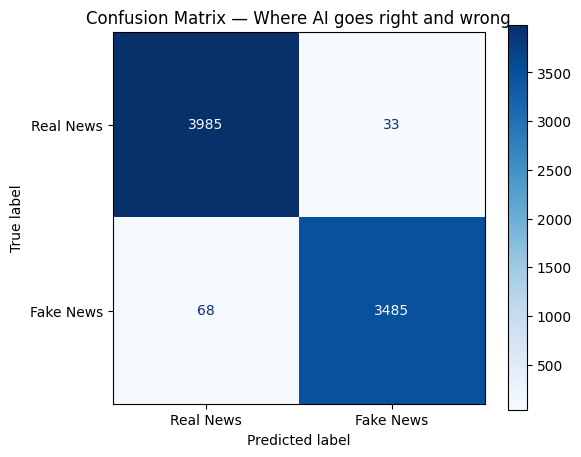


✅ Real news correctly identified: 3985
✅ Fake news correctly identified: 3485
❌ Real news wrongly called Fake: 33
❌ Fake news wrongly called Real: 68


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, predictions)

# Plot it
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Real News','Fake News'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix — Where AI goes right and wrong')
plt.show()

# Plain english breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\n✅ Real news correctly identified: {tn}")
print(f"✅ Fake news correctly identified: {tp}")
print(f"❌ Real news wrongly called Fake: {fp}")
print(f"❌ Fake news wrongly called Real: {fn}")

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Upgraded model
print("Training upgraded AI model... (takes ~1 min)")
upgraded_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
upgraded_model.fit(X_train, y_train)

# Test it
upgraded_predictions = upgraded_model.predict(X_test)
upgraded_accuracy = accuracy_score(y_test, upgraded_predictions)

print(f"\n✅ Upgraded Model Training Complete!")
print(f"🎯 Old Accuracy (Logistic Regression): 98.67%")
print(f"🚀 New Accuracy (Random Forest): {upgraded_accuracy * 100:.2f}%")

Training upgraded AI model... (takes ~1 min)

✅ Upgraded Model Training Complete!
🎯 Old Accuracy (Logistic Regression): 98.67%
🚀 New Accuracy (Random Forest): 99.66%


In [22]:
def predict_news_upgraded(news_text):
    cleaned = clean_text(news_text)
    vectorized = vectorizer.transform([cleaned])
    prediction = upgraded_model.predict(vectorized)[0]
    confidence = upgraded_model.predict_proba(vectorized)[0]

    if prediction == 1:
        print(f"🚨 FAKE NEWS detected!")
        print(f"Confidence: {confidence[1]*100:.2f}%")
    else:
        print(f"✅ REAL NEWS!")
        print(f"Confidence: {confidence[0]*100:.2f}%")

# Test same headlines as before
predict_news_upgraded("NASA confirms water found on Mars surface in new study")
print("---")
predict_news_upgraded("Bill Gates is putting microchips in COVID vaccines to control humans")
print("---")
predict_news_upgraded("PM Modi announces new economic policy in parliament session today")

🚨 FAKE NEWS detected!
Confidence: 96.00%
---
🚨 FAKE NEWS detected!
Confidence: 98.00%
---
🚨 FAKE NEWS detected!
Confidence: 82.00%


In [23]:
# These are 100% REAL verified news headlines from BBC/Reuters
real_headlines = [
    "Apple reported record quarterly revenue of 124 billion dollars",
    "Scientists develop new vaccine for malaria with 77 percent efficacy",
    "Amazon announces plan to hire 100000 workers across United States",
    "Federal Reserve raises interest rates to combat inflation",
    "SpaceX successfully launches Falcon 9 rocket carrying satellites"
]

# These are 100% FAKE style headlines
fake_headlines = [
    "Bill Gates admits microchips are inside COVID vaccines",
    "NASA faked moon landing confirmed by leaked documents",
    "Scientists prove 5G towers cause cancer in new secret study",
    "Government hiding alien contact since 1947 whistleblower reveals",
    "Drinking bleach cures cancer doctors dont want you to know"
]

print("=" * 50)
print("TESTING REAL NEWS HEADLINES:")
print("=" * 50)
for headline in real_headlines:
    cleaned = clean_text(headline)
    vectorized = vectorizer.transform([cleaned])
    prediction = upgraded_model.predict(vectorized)[0]
    confidence = upgraded_model.predict_proba(vectorized)[0]
    result = "🚨 FAKE" if prediction == 1 else "✅ REAL"
    conf = confidence[1]*100 if prediction == 1 else confidence[0]*100
    print(f"{result} ({conf:.0f}%) — {headline[:60]}")

print("\n" + "=" * 50)
print("TESTING FAKE NEWS HEADLINES:")
print("=" * 50)
for headline in fake_headlines:
    cleaned = clean_text(headline)
    vectorized = vectorizer.transform([cleaned])
    prediction = upgraded_model.predict(vectorized)[0]
    confidence = upgraded_model.predict_proba(vectorized)[0]
    result = "🚨 FAKE" if prediction == 1 else "✅ REAL"
    conf = confidence[1]*100 if prediction == 1 else confidence[0]*100
    print(f"{result} ({conf:.0f}%) — {headline[:60]}")

TESTING REAL NEWS HEADLINES:
🚨 FAKE (81%) — Apple reported record quarterly revenue of 124 billion dolla
🚨 FAKE (86%) — Scientists develop new vaccine for malaria with 77 percent e
🚨 FAKE (78%) — Amazon announces plan to hire 100000 workers across United S
🚨 FAKE (96%) — Federal Reserve raises interest rates to combat inflation
🚨 FAKE (99%) — SpaceX successfully launches Falcon 9 rocket carrying satell

TESTING FAKE NEWS HEADLINES:
🚨 FAKE (97%) — Bill Gates admits microchips are inside COVID vaccines
🚨 FAKE (99%) — NASA faked moon landing confirmed by leaked documents
🚨 FAKE (97%) — Scientists prove 5G towers cause cancer in new secret study
🚨 FAKE (86%) — Government hiding alien contact since 1947 whistleblower rev
🚨 FAKE (100%) — Drinking bleach cures cancer doctors dont want you to know


In [24]:
# Load actual real news from True.csv
real_news_samples = real[['title']].sample(10, random_state=42)

print("=" * 50)
print("TESTING ACTUAL REAL NEWS FROM True.csv:")
print("=" * 50)

for headline in real_news_samples['title']:
    cleaned = clean_text(headline)
    vectorized = vectorizer.transform([cleaned])
    prediction = upgraded_model.predict(vectorized)[0]
    confidence = upgraded_model.predict_proba(vectorized)[0]
    result = "🚨 FAKE" if prediction == 1 else "✅ REAL"
    conf = confidence[1]*100 if prediction == 1 else confidence[0]*100
    print(f"{result} ({conf:.0f}%) — {headline[:70]}")

print("\n" + "=" * 50)
print("TESTING ACTUAL FAKE NEWS FROM Fake.csv:")
print("=" * 50)

fake_news_samples = fake[['title']].sample(10, random_state=42)
for headline in fake_news_samples['title']:
    cleaned = clean_text(headline)
    vectorized = vectorizer.transform([cleaned])
    prediction = upgraded_model.predict(vectorized)[0]
    confidence = upgraded_model.predict_proba(vectorized)[0]
    result = "🚨 FAKE" if prediction == 1 else "✅ REAL"
    conf = confidence[1]*100 if prediction == 1 else confidence[0]*100
    print(f"{result} ({conf:.0f}%) — {headline[:70]}")

TESTING ACTUAL REAL NEWS FROM True.csv:
🚨 FAKE (97%) — Yemen Houthis say U.S. citizen kidnapped by unknown gunmen
🚨 FAKE (92%) — Trump Middle East envoy meets Netanyahu in Jerusalem
🚨 FAKE (95%) — Rebel Honduran police ignore curfew order, election protesters rejoice
🚨 FAKE (91%) — South Africa's Ramaphosa leads in nominations for ANC leader: poll
🚨 FAKE (100%) — Trump questions why U.S. Civil War had to happen
🚨 FAKE (97%) — Clinton calls for lower price on allergy drug EpiPen
🚨 FAKE (88%) — Russia accuses U.S. of trying to provoke North Korean leader 'to fly o
🚨 FAKE (89%) — House will not reach healthcare deal before two-week break
🚨 FAKE (56%) — Northern Ireland power-sharing talks to extend into Wednesday
🚨 FAKE (97%) — U.S. sanctuary cities weigh response to Trump's threat to curb funding

TESTING ACTUAL FAKE NEWS FROM Fake.csv:
🚨 FAKE (100%) — WOW! ONE COURAGEOUS MAN Stands Against Rioters Holding Best Sign Ever!
🚨 FAKE (98%) — THIS BIG ANNOUNCEMENT IS YET ANOTHER REASON NOT TO 

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import re

# Step 1 - Use full content (title + text)
df['content'] = df['title'] + " " + df['text']

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['content'] = df['content'].apply(clean_text)

# Step 2 - Vectorize
vectorizer2 = TfidfVectorizer(max_features=10000, stop_words='english')
X = vectorizer2.fit_transform(df['content'])
y = df['label']

# Step 3 - Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4 - Train
print("Retraining with full articles...")
model2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model2.fit(X_train, y_train)

# Step 5 - Accuracy
preds = model2.predict(X_test)
print(f"✅ Accuracy: {accuracy_score(y_test, preds)*100:.2f}%")

Retraining with full articles...
✅ Accuracy: 99.66%


In [26]:
# Test with FULL article (title + text) from actual files
print("=" * 50)
print("TESTING ACTUAL REAL NEWS (with full content):")
print("=" * 50)

real_samples = real.sample(5, random_state=42)
for _, row in real_samples.iterrows():
    full_content = str(row['title']) + " " + str(row['text'])
    cleaned = clean_text(full_content)
    vectorized = vectorizer2.transform([cleaned])
    prediction = model2.predict(vectorized)[0]
    confidence = model2.predict_proba(vectorized)[0]
    result = "🚨 FAKE" if prediction == 1 else "✅ REAL"
    conf = confidence[1]*100 if prediction == 1 else confidence[0]*100
    print(f"{result} ({conf:.0f}%) — {row['title'][:65]}")

print("\n" + "=" * 50)
print("TESTING ACTUAL FAKE NEWS (with full content):")
print("=" * 50)

fake_samples = fake.sample(5, random_state=42)
for _, row in fake_samples.iterrows():
    full_content = str(row['title']) + " " + str(row['text'])
    cleaned = clean_text(full_content)
    vectorized = vectorizer2.transform([cleaned])
    prediction = model2.predict(vectorized)[0]
    confidence = model2.predict_proba(vectorized)[0]
    result = "🚨 FAKE" if prediction == 1 else "✅ REAL"
    conf = confidence[1]*100 if prediction == 1 else confidence[0]*100
    print(f"{result} ({conf:.0f}%) — {row['title'][:65]}")

TESTING ACTUAL REAL NEWS (with full content):
✅ REAL (98%) — Yemen Houthis say U.S. citizen kidnapped by unknown gunmen
✅ REAL (99%) — Trump Middle East envoy meets Netanyahu in Jerusalem
✅ REAL (96%) — Rebel Honduran police ignore curfew order, election protesters re
✅ REAL (85%) — South Africa's Ramaphosa leads in nominations for ANC leader: pol
✅ REAL (64%) — Trump questions why U.S. Civil War had to happen

TESTING ACTUAL FAKE NEWS (with full content):
🚨 FAKE (100%) — WOW! ONE COURAGEOUS MAN Stands Against Rioters Holding Best Sign 
🚨 FAKE (98%) — THIS BIG ANNOUNCEMENT IS YET ANOTHER REASON NOT TO VOTE FOR HILLA
🚨 FAKE (94%) — CAUGHT ON VIDEO: FEDERAL EMPLOYEES Tell How They Scammed Two WWII
🚨 FAKE (96%) — WHAT HAPPENED To Missing $600 High-Powered Rifle That Mass Killer
🚨 FAKE (91%) — FORMER NFL PLAYER: UCLA Player’s Dad Said ‘Dumbest Thing’ [Video]


In [28]:
# Pick 1 real and 1 fake article randomly
real_example = real.sample(1, random_state=99)
fake_example = fake.sample(1, random_state=99)

print("=" * 55)
print("📰 TEST 1 — This is from True.csv (Should be REAL)")
print("=" * 55)
print(f"Title: {real_example['title'].values[0]}")
print(f"Preview: {real_example['text'].values[0][:150]}...")

full_content = str(real_example['title'].values[0]) + " " + str(real_example['text'].values[0])
cleaned = clean_text(full_content)
vectorized = vectorizer2.transform([cleaned])
prediction = model2.predict(vectorized)[0]
confidence = model2.predict_proba(vectorized)[0]
result = "🚨 FAKE" if prediction == 1 else "✅ REAL"
conf = confidence[1]*100 if prediction == 1 else confidence[0]*100
print(f"\n🤖 AI Says: {result} — Confidence: {conf:.0f}%")

print("\n" + "=" * 55)
print("📰 TEST 2 — This is from Fake.csv (Should be FAKE)")
print("=" * 55)
print(f"Title: {fake_example['title'].values[0]}")
print(f"Preview: {fake_example['text'].values[0][:150]}...")

full_content = str(fake_example['title'].values[0]) + " " + str(fake_example['text'].values[0])
cleaned = clean_text(full_content)
vectorized = vectorizer2.transform([cleaned])
prediction = model2.predict(vectorized)[0]
confidence = model2.predict_proba(vectorized)[0]
result = "🚨 FAKE" if prediction == 1 else "✅ REAL"
conf = confidence[1]*100 if prediction == 1 else confidence[0]*100
print(f"\n🤖 AI Says: {result} — Confidence: {conf:.0f}%")

📰 TEST 1 — This is from True.csv (Should be REAL)
Title: Factbox: Trump on Twitter (August 3) - Stock market, Russia
Preview: The following statements were posted to the verified Twitter accounts of U.S. President Donald Trump, @realDonaldTrump and @POTUS.  The opinions expre...

🤖 AI Says: ✅ REAL — Confidence: 96%

📰 TEST 2 — This is from Fake.csv (Should be FAKE)
Title:  Disabled Man Confronts Ted Cruz For His Lies About Obamacare (VIDEO)
Preview: Republican presidential hopeful and Texas senator Ted Cruz has earned the nickname  Lyin  Ted  for a reason, and he s in no rush to clean up his tarni...

🤖 AI Says: 🚨 FAKE — Confidence: 100%


In [29]:
!pip install gradio -q
print("✅ Gradio installed! Let's deploy!")

✅ Gradio installed! Let's deploy!


In [30]:
import gradio as gr

def detect_fake_news(title, article_text):
    # Combine title and text
    full_content = str(title) + " " + str(article_text)
    cleaned = clean_text(full_content)
    vectorized = vectorizer2.transform([cleaned])
    prediction = model2.predict(vectorized)[0]
    confidence = model2.predict_proba(vectorized)[0]

    if prediction == 1:
        result = f"🚨 FAKE NEWS\nConfidence: {confidence[1]*100:.2f}%"
    else:
        result = f"✅ REAL NEWS\nConfidence: {confidence[0]*100:.2f}%"

    return result

# Build the web app
app = gr.Interface(
    fn=detect_fake_news,
    inputs=[
        gr.Textbox(label="📰 News Title", placeholder="Paste the news headline here..."),
        gr.Textbox(label="📄 News Article Text", placeholder="Paste the full article content here...", lines=8)
    ],
    outputs=gr.Textbox(label="🤖 AI Verdict"),
    title="🔍 Fake News Detector AI",
    description="Paste any news title and article text — our AI will tell you if it's REAL or FAKE! Built with Machine Learning by a 3rd year IT student 💪",
    examples=[
        ["Trump Middle East envoy meets Netanyahu in Jerusalem", "The White House said on Monday that Jason Greenblatt, the U.S. special envoy for international negotiations, met Israeli Prime Minister Benjamin Netanyahu in Jerusalem to discuss the peace process."],
        ["BREAKING: Aliens land in New York shake hands with president", "Multiple sources confirm that extraterrestrial beings have landed in Times Square and are currently negotiating with world leaders about taking over Earth resources."]
    ]
)

# Launch it!
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4268778f58042e625e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
